In [1]:
import serial
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Configure the serial connection settings
serial_port = 'COM7' #'/dev/ttyACM0'  # Linux example, Windows: COM3, Mac: /dev/tty.usbmodem14101
baud_rate = 9600  # Match the baud rate to your Arduino's
output_file_path = 'bench_yaw.txt'
len_ts = 23

In [77]:


# Open the serial port
with serial.Serial(serial_port, baud_rate) as ser, open(output_file_path, 'a') as outfile:
    print(f"Started reading from {serial_port} at {baud_rate} baud rate.")
    
    try:
        while True:
            # Read a line from the serial port
            line = ser.readline().decode('utf-8').strip()
            
            # Get the current timestamp
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')[:len_ts]
            
            # Format the data with the timestamp
            data_with_timestamp = f"{timestamp}: {line}"
            
            # Print to console (optional)
            print(data_with_timestamp)
            
            # Append to the file
            outfile.write(data_with_timestamp + '\n')
            outfile.flush()  # Ensure data is written to file immediately
            
    except KeyboardInterrupt:
        print("Stopped by user.")


Started reading from COM7 at 9600 baud rate.
2024-04-23 17:28:59.360: IMU: aX =   1036 | aY =    -68 | aZ =  18664 | Temp = 22.51 | gX =  -1188 | gY =    497 | gZ =    123
2024-04-23 17:28:59.561: IMU: aX =   -312 | aY =     80 | aZ =  18544 | Temp = 22.46 | gX =   -804 | gY =    767 | gZ =   -144
2024-04-23 17:28:59.762: IMU: aX =  -1332 | aY =   -480 | aZ =  17824 | Temp = 22.46 | gX =    589 | gY =    216 | gZ =    460
2024-04-23 17:28:59.963: IMU: aX =    364 | aY =    216 | aZ =  18584 | Temp = 22.46 | gX =   -343 | gY =    -90 | gZ =   -339
2024-04-23 17:29:00.164: IMU: aX =   -768 | aY =   -524 | aZ =  18312 | Temp = 22.46 | gX =   1008 | gY =    928 | gZ =     13
2024-04-23 17:29:00.204: Wind: Speed = 0.00 km/h, Direction = 0
2024-04-23 17:29:00.381: IMU: aX =   -768 | aY =   1332 | aZ =  17196 | Temp = 22.60 | gX =  -1019 | gY =    247 | gZ =    680
2024-04-23 17:29:00.581: IMU: aX =     72 | aY =   -440 | aZ =  18612 | Temp = 22.60 | gX =   1038 | gY =    272 | gZ =   1399
20

In [2]:
def calculate_orientation(x_acc, y_acc, z_acc):
    roll = math.atan2(y_acc, z_acc)
    pitch = math.atan2(-x_acc, math.sqrt(y_acc**2 + z_acc**2))
    #roll_degrees = roll * (180 / math.pi)
    #pitch_degrees = pitch * (180 / math.pi)
    return roll, pitch

def parse_stream(pth):
    ts_format = '%Y-%m-%d %H:%M:%S.%f'
    with open(pth) as f:
        imu_rows = []
        wind_rows = []
        start_dt = None
        for i, l in enumerate(f):
            ts = l[:len_ts]
            if i == 0:
                start_dt = datetime.strptime(ts, ts_format)
            dt = datetime.strptime(ts, ts_format)
            elapsed = int((dt - start_dt).total_seconds() * 1000)
            row_dict = {'time':ts, 'elapsed':elapsed}
            try:
                sensor, dat = l[len_ts + 2:].split(':')
            except:
                print(l[len_ts + 2:])
            dat = dat.strip()
            if sensor == 'IMU':
                dat = dat.split('|')
                for read in dat:
                    k, v = read.split('=')
                    k, v = k.strip(), v.strip()
                    row_dict[k] = v
                row_dict['roll'], row_dict['pitch'] = calculate_orientation(int(row_dict['aX']), int(row_dict['aY']), int(row_dict['aZ']))
                imu_rows.append(row_dict)
            if sensor =='Wind':
                dat = dat.split(',')
                for read in dat:
                    k,v = read.split('=')
                    k,v = k.strip(), v.split(' ')[1]
                    #if k == 'Speed':
                    #    v = float(v)
                    #elif k == '':
                    row_dict[k] = v
                    wind_rows.append(row_dict)
    imu_df, wind_df = pd.DataFrame(imu_rows), pd.DataFrame(wind_rows)
    imu_df = imu_df.astype({'aX':int, 'aY':int, 'aZ':int, 'Temp':float, 'gX':int, 'gY':int, 'gZ':int})
    wind_df = wind_df.astype({'Speed':float, 'Direction':int})
    return imu_df, wind_df


In [5]:
imu_df, wind_df = parse_stream('wind_data/bench_pitch.txt')


In [6]:
imu_df

,time,elapsed,aX,aY,aZ,Temp,gX,gY,gZ,roll,pitch
0,2024-04-23 16:58:03.573,0,1072,-1260,18264,22.37,-517,4,44,-0.068879,-0.058489
1,2024-04-23 16:58:03.773,200,800,-1464,18048,22.22,-175,-44,-190,-0.080940,-0.044152
2,2024-04-23 16:58:03.974,401,1136,-1216,18068,22.27,-91,73,-32,-0.067200,-0.062650
3,2024-04-23 16:58:04.174,601,552,-1852,18036,22.37,-153,303,453,-0.102325,-0.030436
4,2024-04-23 16:58:04.376,803,996,-1564,18280,22.32,-481,-44,-143,-0.085350,-0.054234
...,...,...,...,...,...,...,...,...,...,...,...
463,2024-04-23 16:59:37.795,94222,-3668,-548,17764,23.02,-300,-148,-188,-0.030839,0.203529
464,2024-04-23 16:59:37.995,94422,-3556,-228,17996,23.07,-93,23,370,-0.012669,0.195071
465,2024-04-23 16:59:38.212,94639,-3440,-472,17740,23.07,-73,64,-55,-0.026600,0.191469
466,2024-04-23 16:59:38.407,94834,-3572,-568,17736,23.12,-564,-66,-163,-0.032014,0.198641


In [7]:
wind_df

,time,elapsed,Speed,Direction
0,2024-04-23 16:58:04.416,843,10.91,32
1,2024-04-23 16:58:04.416,843,10.91,32
2,2024-04-23 16:58:05.437,1864,11.02,31
3,2024-04-23 16:58:05.437,1864,11.02,31
4,2024-04-23 16:58:06.456,2883,11.09,32
...,...,...,...,...
181,2024-04-23 16:59:36.009,92436,10.37,28
182,2024-04-23 16:59:37.019,93446,10.55,27
183,2024-04-23 16:59:37.019,93446,10.55,27
184,2024-04-23 16:59:38.034,94461,10.73,26


<Axes: >

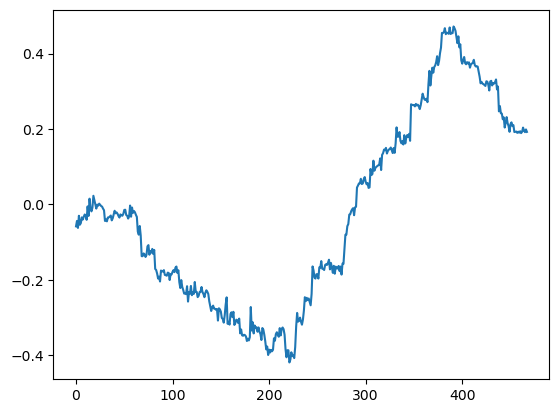

In [13]:
imu_df['pitch'].plot()

In [71]:
wind_df

,time,elapsed,Speed,Direction,w_x_sensor,w_y_sensor
0,2024-04-23 16:58:04.416,843,10.91,32,5.781419,9.252205
1,2024-04-23 16:58:04.416,843,10.91,32,5.781419,9.252205
2,2024-04-23 16:58:05.437,1864,11.02,31,5.675720,9.445984
3,2024-04-23 16:58:05.437,1864,11.02,31,5.675720,9.445984
4,2024-04-23 16:58:06.456,2883,11.09,32,5.876805,9.404853
...,...,...,...,...,...,...
181,2024-04-23 16:59:36.009,92436,10.37,28,4.868420,9.156167
182,2024-04-23 16:59:37.019,93446,10.55,27,4.789600,9.400119
183,2024-04-23 16:59:37.019,93446,10.55,27,4.789600,9.400119
184,2024-04-23 16:59:38.034,94461,10.73,26,4.703722,9.644060


(-12.0, 12.0)

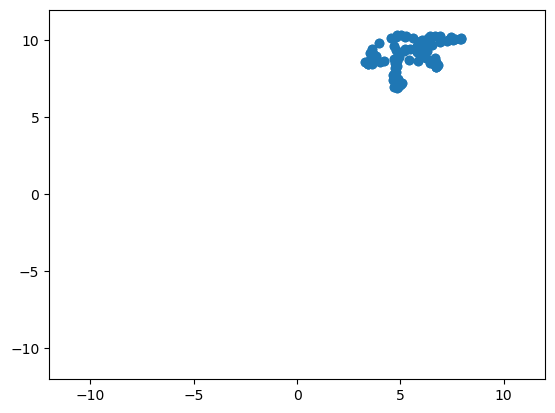

In [76]:
plt.scatter(wind_df['w_x_sensor'],wind_df['w_y_sensor'])
plt.xlim(-12,12)
plt.ylim(-12,12)

In [14]:
len(imu_df)

468

In [15]:
len(wind_df)

186

In [14]:
def vectorized_vector_components(magnitude, angle_from_y_axis):
    # Convert angle from degrees to radians
    angle_radians = np.radians(angle_from_y_axis)
    
    # Calculate the angle from the x-axis (90 degrees - angle)
    angle_from_x_axis = np.radians(90) - angle_radians
    
    # Calculate the components using numpy's vectorized functions
    x_component = magnitude * np.cos(angle_from_x_axis)
    y_component = magnitude * np.sin(angle_from_x_axis)
    
    return x_component, y_component
wind_df['w_x_sensor'], wind_df['w_y_sensor']= vectorized_vector_components(wind_df['Speed'], wind_df['Direction'])

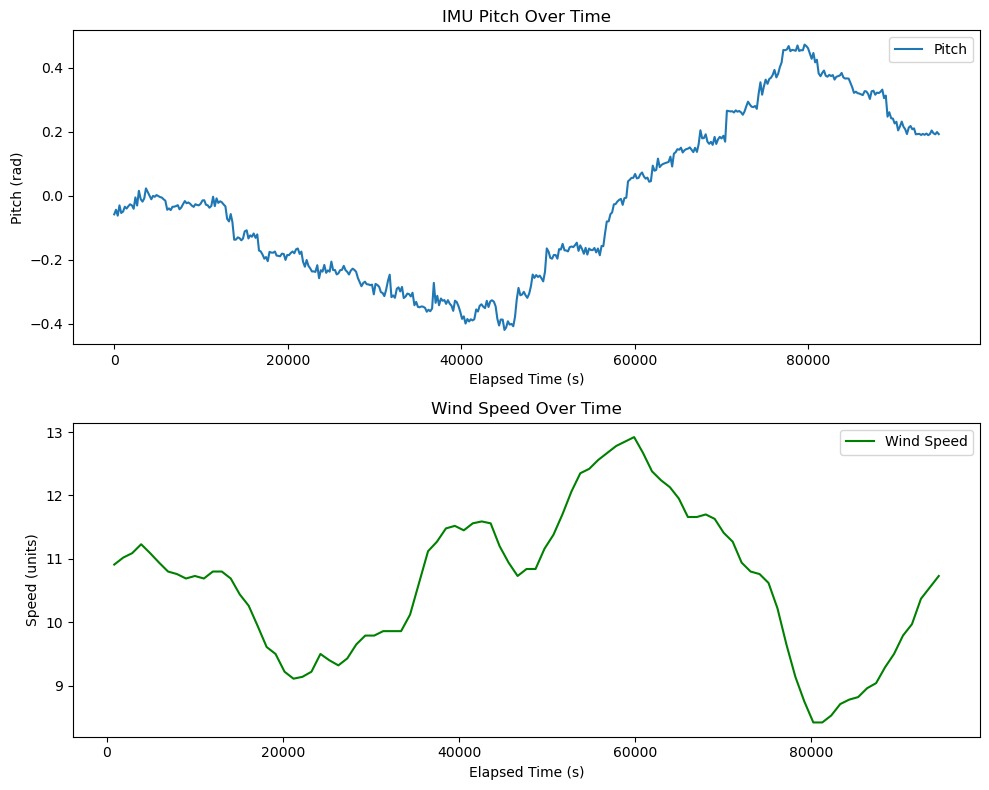

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(imu_df['elapsed'], imu_df['pitch'], label='Pitch')
axs[0].set_title('IMU Pitch Over Time')
axs[0].set_xlabel('Elapsed Time (s)')
axs[0].set_ylabel('Pitch (rad)')
axs[0].legend()

# Second subplot for Wind Speed data
axs[1].plot(wind_df['elapsed'], wind_df['Speed'], label='Wind Speed', color='green')
axs[1].set_title('Wind Speed Over Time')
axs[1].set_xlabel('Elapsed Time (s)')
axs[1].set_ylabel('Speed (units)')
axs[1].legend()
plt.tight_layout()
plt.show()

In [90]:
time = 20000
imu_df.loc[(imu_df['elapsed'] - time).abs() < 500, ['aX', 'aY', 'aZ', 'Temp', 'gX','gY', 'gZ','roll', 'pitch']].mean()

aX        3376.800000
aY       -3918.400000
aZ       17441.600000
Temp        22.536000
gX         -88.400000
gY         102.200000
gZ        -164.600000
roll        -0.220981
pitch       -0.186700
dtype: float64

In [16]:
cols = ['aX', 'aY', 'aZ', 'Temp', 'gX','gY', 'gZ','roll', 'pitch']
def create_master_df(wind_df, imu_df):
    for col in cols:
        wind_df[col] = pd.NA
    for i,r in wind_df.iterrows():
        time = r['elapsed']
        reads = imu_df.loc[(imu_df['elapsed'] - time).abs() < 500, cols].mean()
        reads['elapsed'] = time
        for col in reads.index:
            wind_df.at[i, col] = reads[col]
    return wind_df
sensor_df = create_master_df(wind_df, imu_df)
sensor_df

,time,elapsed,Speed,Direction,aX,aY,aZ,Temp,gX,gY,gZ,roll,pitch,w_x_sensor,w_y_sensor
0,2024-04-23 16:58:04.416,843,10.91,32,844.0,-1628.8,18117.6,22.31,-220.4,133.2,103.0,-0.08966,-0.046337,5.781419,9.252205
1,2024-04-23 16:58:04.416,843,10.91,32,844.0,-1628.8,18117.6,22.31,-220.4,133.2,103.0,-0.08966,-0.046337,5.781419,9.252205
2,2024-04-23 16:58:05.437,1864,11.02,31,628.0,-1611.2,18110.4,22.28,-115.4,44.6,125.8,-0.088718,-0.034483,5.675720,9.445984
3,2024-04-23 16:58:05.437,1864,11.02,31,628.0,-1611.2,18110.4,22.28,-115.4,44.6,125.8,-0.088718,-0.034483,5.675720,9.445984
4,2024-04-23 16:58:06.456,2883,11.09,32,186.4,-977.6,18184.8,22.394,182.0,48.6,366.0,-0.053734,-0.010349,5.876805,9.404853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,2024-04-23 16:59:36.009,92436,10.37,28,-3579.2,-204.0,17760.0,23.024,-326.6,-213.6,-116.0,-0.011491,0.198841,4.868420,9.156167
182,2024-04-23 16:59:37.019,93446,10.55,27,-3457.6,-372.0,17880.8,23.07,-348.6,-61.6,-85.2,-0.020789,0.190967,4.789600,9.400119
183,2024-04-23 16:59:37.019,93446,10.55,27,-3457.6,-372.0,17880.8,23.07,-348.6,-61.6,-85.2,-0.020789,0.190967,4.789600,9.400119
184,2024-04-23 16:59:38.034,94461,10.73,26,-3547.2,-472.8,17838.4,23.06,-198.0,-43.0,-39.4,-0.026526,0.196226,4.703722,9.644060


In [20]:
fig, ax = plt.subplot(2)
plt.scatter(sensor_df['pitch'], sensor_df['w_y_sensor'])

ValueError: Single argument to subplot must be a three-digit integer, not 2

<Figure size 640x480 with 0 Axes>

In [9]:
imu_df = imu_df.astype({'aX':int, 'aY':int, 'aZ':int, 'Temp':float, 'gX':int, 'gY':int, 'gZ':int})
imu_df['aX']

0      1072
1       800
2      1136
3       552
4       996
       ... 
463   -3668
464   -3556
465   -3440
466   -3572
467   -3484
Name: aX, Length: 468, dtype: int32

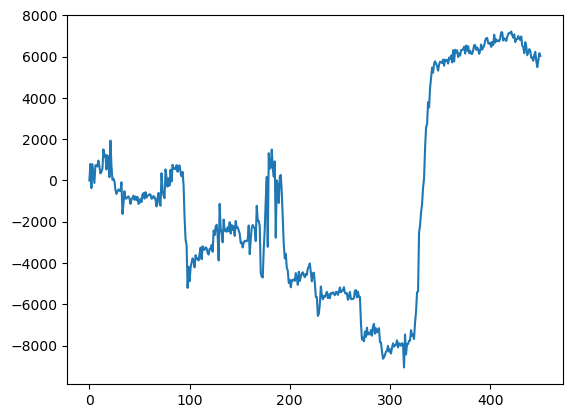

In [24]:
plt.plot(imu_df['aX'])

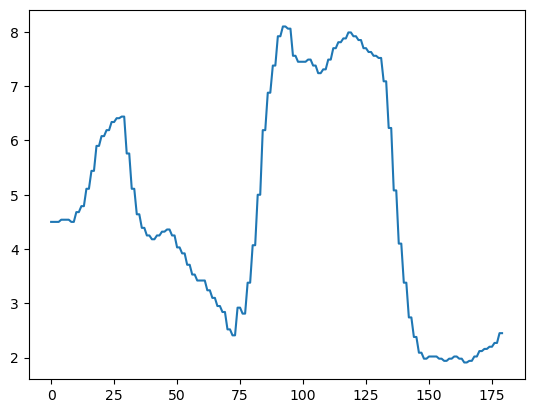

In [22]:
import matplotlib.pyplot as plt
plt.plot(wind_df['Speed'].astype(float))

In [4]:
import pandas as pd
df = pd.read_csv('new_file.txt', sep = '\t')
df

,2024-04-05 14:14:53: IMU: aX = 724 | aY = 768 | aZ = 18004 | Temp = 23.87 | gX = -228 | gY = -29 | gZ = -74
0,"2024-04-05 14:14:53: Wind: Speed = 0.00 km/h, ..."
1,2024-04-05 14:14:54: IMU: aX = 768 | aY = ...
2,"2024-04-05 14:14:55: Wind: Speed = 0.00 km/h, ..."
3,2024-04-05 14:14:56: IMU: aX = 740 | aY = ...
4,"2024-04-05 14:14:56: Wind: Speed = 0.00 km/h, ..."
...,...
232,"2024-04-05 14:19:36: Wind: Speed = 0.00 km/h, ..."
233,2024-04-05 14:19:37: IMU: aX = 664 | aY = ...
234,"2024-04-05 14:19:37: Wind: Speed = 0.00 km/h, ..."
235,2024-04-05 14:19:38: IMU: aX = 656 | aY = ...
